In [12]:
import os

dataset_path = r"E:\Pyhton code\Data Sets\archive\Plant Disease Dataset\PlantVillage"

for folder in os.listdir(dataset_path):
    print(folder)

Pepper__bell___Bacterial_spot
Pepper__bell___healthy
PlantVillage
Potato___Early_blight
Potato___healthy
Potato___Late_blight
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_healthy
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_mosaic_virus
Tomato__Tomato_YellowLeaf__Curl_Virus


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [14]:
classes = sorted(os.listdir(dataset_path))

print("Number of classes:", len(classes))
print()

for cls in classes:
    print(cls)

Number of classes: 16

Pepper__bell___Bacterial_spot
Pepper__bell___healthy
PlantVillage
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato__Tomato_mosaic_virus
Tomato_healthy


In [15]:
#Count image per class
class_counts = {}

for cls in classes:
    
    class_path = os.path.join(dataset_path, cls)

    image_count = len(os.listdir(class_path))

    class_counts[cls] = image_count

class_counts

{'Pepper__bell___Bacterial_spot': 997,
 'Pepper__bell___healthy': 1478,
 'PlantVillage': 15,
 'Potato___Early_blight': 1000,
 'Potato___Late_blight': 1000,
 'Potato___healthy': 152,
 'Tomato_Bacterial_spot': 2127,
 'Tomato_Early_blight': 1000,
 'Tomato_Late_blight': 1909,
 'Tomato_Leaf_Mold': 952,
 'Tomato_Septoria_leaf_spot': 1771,
 'Tomato_Spider_mites_Two_spotted_spider_mite': 1676,
 'Tomato__Target_Spot': 1404,
 'Tomato__Tomato_YellowLeaf__Curl_Virus': 3209,
 'Tomato__Tomato_mosaic_virus': 373,
 'Tomato_healthy': 1591}

In [16]:
#Convert to dataframe
df = pd.DataFrame(
    class_counts.items(),
    columns=["Class","Count"]
)

df

,Class,Count
0,Pepper__bell___Bacterial_spot,997
1,Pepper__bell___healthy,1478
2,PlantVillage,15
3,Potato___Early_blight,1000
4,Potato___Late_blight,1000
5,Potato___healthy,152
6,Tomato_Bacterial_spot,2127
7,Tomato_Early_blight,1000
8,Tomato_Late_blight,1909
9,Tomato_Leaf_Mold,952


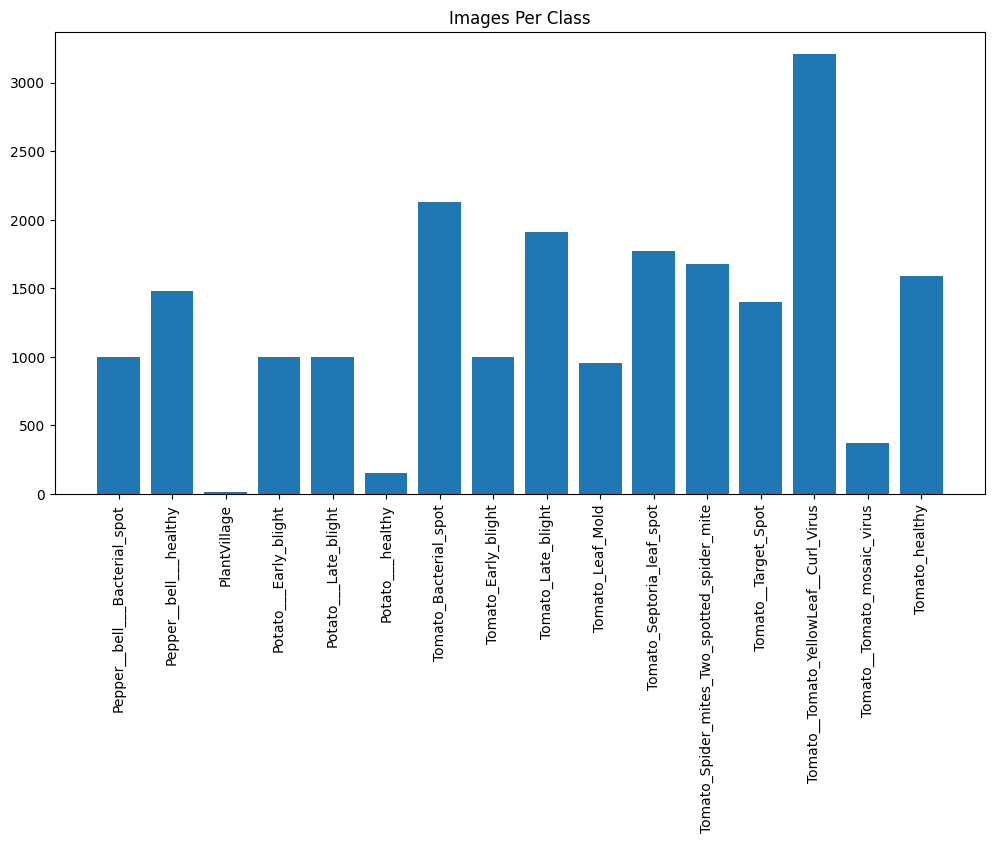

In [17]:
plt.figure(figsize=(12,6))

plt.bar(df["Class"], df["Count"])

plt.xticks(rotation=90)

plt.title("Images Per Class")

plt.show()

In [18]:
#visiualize sample images
import random
random_class = random.choice(classes)

random_class

'Pepper__bell___healthy'

In [19]:
class_path = os.path.join(dataset_path, random_class)

images = os.listdir(class_path)

sample_image = random.choice(images)

sample_image

'2a5eb7c8-4c8b-43a6-9448-b3983beef06c___JR_HL 8248.JPG'

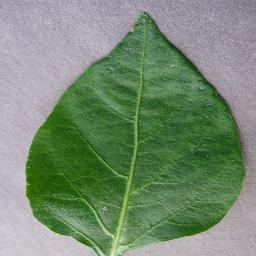

In [20]:
img_path = os.path.join(class_path, sample_image)

img = Image.open(img_path)

img

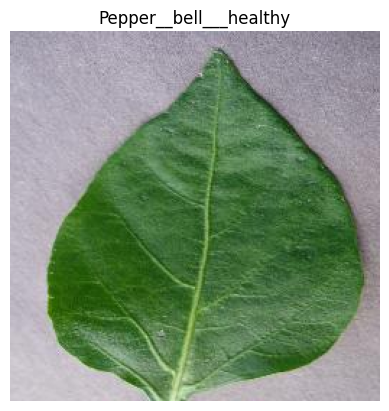

In [21]:
plt.imshow(img)

plt.title(random_class)

plt.axis("off")

plt.show()

In [22]:
for cls in classes:
    print(cls)

Pepper__bell___Bacterial_spot
Pepper__bell___healthy
PlantVillage
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato__Tomato_mosaic_virus
Tomato_healthy


In [23]:
classes = sorted(
    [
        cls
        for cls in os.listdir(dataset_path)
        if cls != "PlantVillage"
    ]
)

In [24]:
print(len(classes))

15


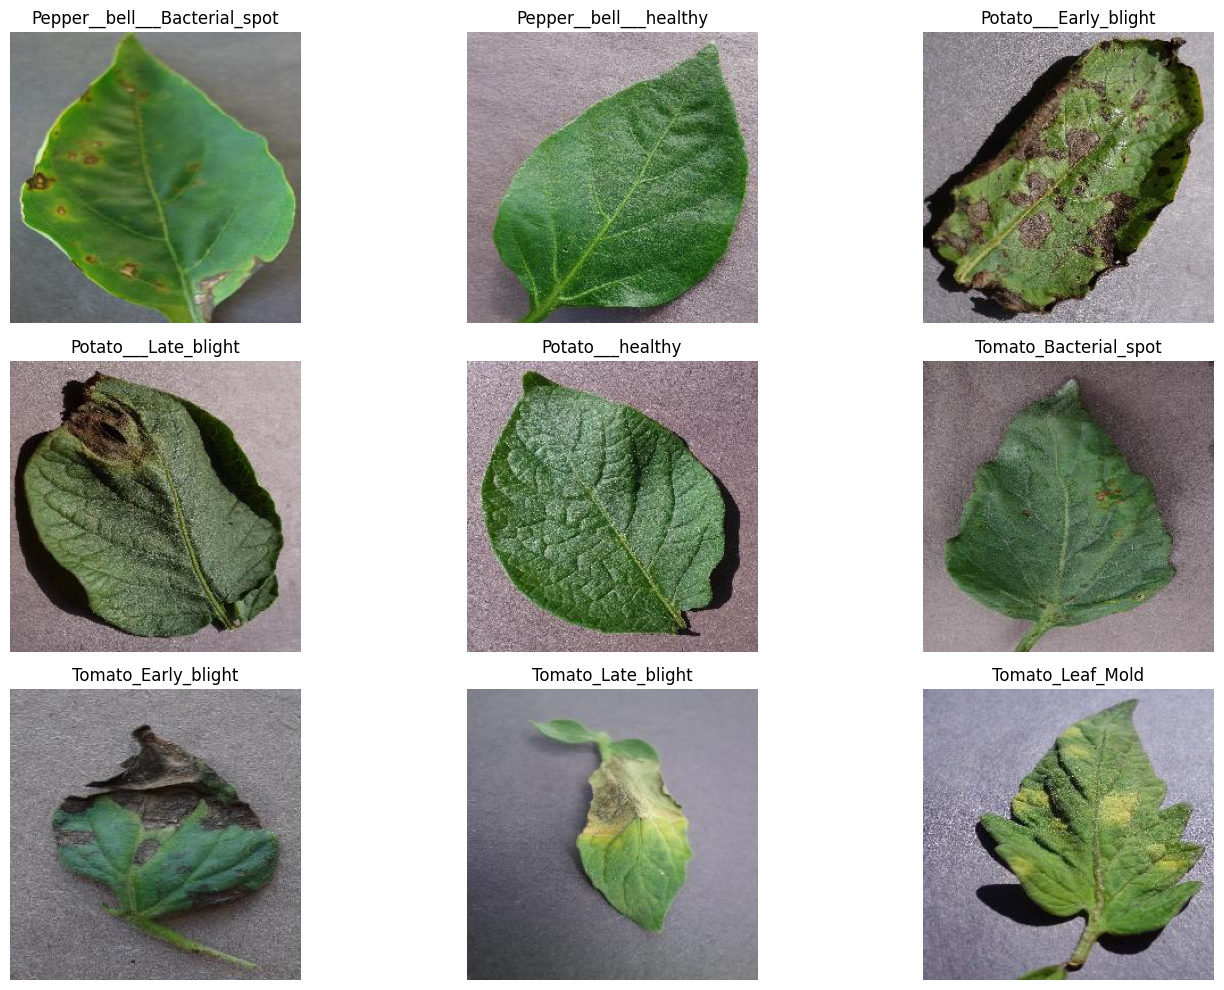

In [25]:
#Visiualize multiple classes
plt.figure(figsize=(15,10))

for i, cls in enumerate(classes[:9]):

    class_path = os.path.join(dataset_path, cls)

    img_name = random.choice(os.listdir(class_path))

    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [26]:
sizes = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path)[:50]:

        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            sizes.append(img.size)

        except:
            pass

In [27]:
set(sizes)

{(256, 256)}

In [28]:
sum(class_counts.values())

20654

In [29]:
from sklearn.model_selection import train_test_split
import os

data = []

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        data.append({
            "filepath": img_path,
            "label": cls
        })

df = pd.DataFrame(data)

print(df.shape)
df.head()

(20639, 2)


,filepath,label
0,E:\Pyhton code\Data Sets\archive\Plant Disease...,Pepper__bell___Bacterial_spot
1,E:\Pyhton code\Data Sets\archive\Plant Disease...,Pepper__bell___Bacterial_spot
2,E:\Pyhton code\Data Sets\archive\Plant Disease...,Pepper__bell___Bacterial_spot
3,E:\Pyhton code\Data Sets\archive\Plant Disease...,Pepper__bell___Bacterial_spot
4,E:\Pyhton code\Data Sets\archive\Plant Disease...,Pepper__bell___Bacterial_spot


In [30]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 14447
Validation: 3096
Test: 3096


In [31]:
train_df["label"].value_counts(normalize=True).head()

label
Tomato__Tomato_YellowLeaf__Curl_Virus          0.155465
Tomato_Bacterial_spot                          0.103066
Tomato_Late_blight                             0.092476
Tomato_Septoria_leaf_spot                      0.085831
Tomato_Spider_mites_Two_spotted_spider_mite    0.081193
Name: proportion, dtype: float64

In [32]:
val_df["label"].value_counts(normalize=True).head()

label
Tomato__Tomato_YellowLeaf__Curl_Virus          0.155362
Tomato_Bacterial_spot                          0.103036
Tomato_Late_blight                             0.092377
Tomato_Septoria_leaf_spot                      0.085594
Tomato_Spider_mites_Two_spotted_spider_mite    0.081072
Name: proportion, dtype: float64

In [62]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras import layers, models

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [63]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=15,

    width_shift_range=0.1,
    height_shift_range=0.1,

    zoom_range=0.15,

    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [64]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,

    x_col="filepath",
    y_col="label",

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=True
)

Found 14446 validated image filenames belonging to 15 classes.


C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\legacy\preprocessing\image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="filepath". These filename(s) will be ignored.
  warnings.warn(


In [65]:
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,

    x_col="filepath",
    y_col="label",

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False
)

Found 3096 validated image filenames belonging to 15 classes.


In [66]:
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,

    x_col="filepath",
    y_col="label",

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False
)

Found 3096 validated image filenames belonging to 15 classes.


In [67]:
X_batch, y_batch = next(train_generator)

print("Image Shape :", X_batch.shape)
print("Label Shape :", y_batch.shape)

print("Min :", X_batch.min())
print("Max :", X_batch.max())

Image Shape : (32, 224, 224, 3)
Label Shape : (32, 15)
Min : 0.0
Max : 254.78677


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..120.94597].


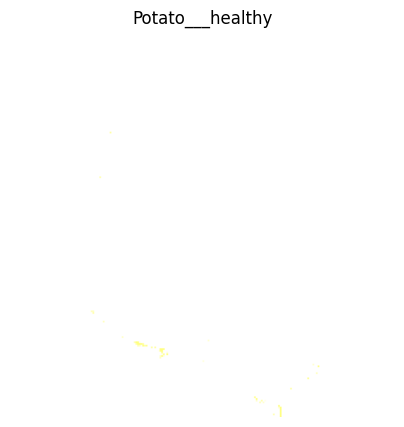

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.imshow((X_batch[0] + 1) / 2)

plt.title(
    list(train_generator.class_indices.keys())[
        np.argmax(y_batch[0])
    ]
)

plt.axis("off")
plt.show()

In [69]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [70]:
model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dropout(0.4),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        15,
        activation="softmax"
    )
])

In [71]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

In [72]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,386,482 (16.73 MB)

 Trainable params: 334,351 (1.28 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [73]:
preds = model.predict(X_batch[:20])

print(np.argmax(preds, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[11  5  5  5 11  5 14 11  5  6 11  5  9  6  5  5  9  5  5  5]


In [74]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",

    factor=0.2,

    patience=3,

    min_lr=1e-6,

    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_plant_disease_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1
)

In [75]:
print(train_generator.class_indices)

print("\nNumber of classes:")
print(len(train_generator.class_indices))

{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}

Number of classes:
15


In [76]:
history = model.fit(
    train_generator,

    validation_data=val_generator,

    epochs=20,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3525 - loss: 2.3581
Epoch 1: val_accuracy improved from None to 0.78811, saving model to best_plant_disease_model.keras

Epoch 1: finished saving model to best_plant_disease_model.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 655s 1s/step - accuracy: 0.5058 - loss: 1.6849 - val_accuracy: 0.7881 - val_loss: 0.7133 - learning_rate: 1.0000e-04
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.7059 - loss: 0.9237
Epoch 2: val_accuracy improved from 0.78811 to 0.84819, saving model to best_plant_disease_model.keras

Epoch 2: finished saving model to best_plant_disease_model.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 266s 587ms/step - accuracy: 0.7212 - loss: 0.8608 - val_accuracy: 0.8482 - val_loss: 0.4710 - learning_rate: 1.0000e-04
Epoch 3/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.7731 - loss: 0.6869
Epoch 3: val_accuracy improved from 0.84819 to 0.87823, saving model to best_plant_disease_model.keras

Epoch

In [77]:
model.save(
    "plant_disease_efficientnet_b0.keras"
)

In [79]:
from tensorflow.keras.models import load_model

best_model = load_model("best_plant_disease_model.keras")

In [80]:
test_loss, test_acc = best_model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

97/97 ━━━━━━━━━━━━━━━━━━━━ 101s 982ms/step - accuracy: 0.9528 - loss: 0.1401
Test Accuracy: 0.9528
Test Loss: 0.1401


In [81]:
import numpy as np

pred_probs = best_model.predict(test_generator)

pred_classes = np.argmax(pred_probs, axis=1)

true_classes = test_generator.classes

97/97 ━━━━━━━━━━━━━━━━━━━━ 56s 560ms/step


In [82]:
from sklearn.metrics import classification_report

class_names = list(test_generator.class_indices.keys())

print(
    classification_report(
        true_classes,
        pred_classes,
        target_names=class_names
    )
)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.99      0.98       149
                     Pepper__bell___healthy       1.00      1.00      1.00       221
                      Potato___Early_blight       0.99      0.99      0.99       150
                       Potato___Late_blight       0.97      0.97      0.97       150
                           Potato___healthy       0.95      0.91      0.93        23
                      Tomato_Bacterial_spot       0.97      0.97      0.97       319
                        Tomato_Early_blight       0.96      0.76      0.85       150
                         Tomato_Late_blight       0.95      0.97      0.96       287
                           Tomato_Leaf_Mold       0.93      0.93      0.93       143
                  Tomato_Septoria_leaf_spot       0.96      0.91      0.93       266
Tomato_Spider_mites_Two_spotted_spider_mite       0.92      0.95

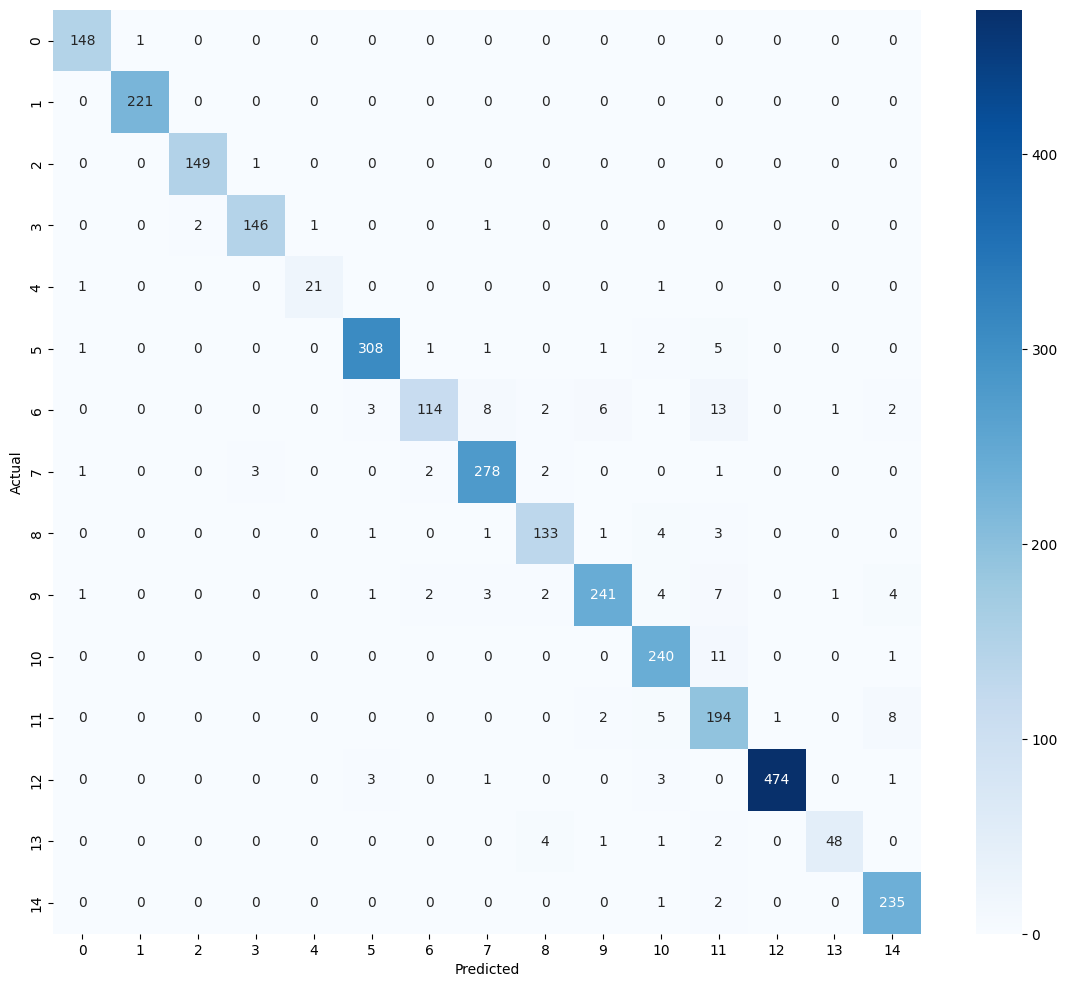

In [83]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_classes,
    pred_classes
)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()